# nano4M — Architecture Improvements: Demo Notebook

Explore any-to-any generation across all trained variants.  
Models are loaded from **HuggingFace** ([Atomium90/nano4M-architecture-ablations](https://huggingface.co/Atomium90/nano4M-architecture-ablations)) and cached locally — no cluster required.

**What you can do:**
- Generate any modality conditioned on any other (Caption → RGB, RGB → Depth → Normals, …)
- Compare baseline vs any variant side-by-side
- Visualise the effect of different architectural choices on generation quality

## 1. Setup

In [1]:
import os, math, textwrap
from pathlib import Path
from PIL import Image

import torch
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yaml, omegaconf
from hydra.utils import instantiate
from huggingface_hub import hf_hub_download

%load_ext autoreload
%autoreload 2

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_grad_enabled(False)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')
print(f'HF cache: {Path.home() / ".cache" / "huggingface" / "hub"}')


Device : cuda
HF cache: /home/picart/.cache/huggingface/hub


### 1.1 Cosmos tokenizer (Cosmos DI16x16)

Downloaded once from HuggingFace and cached locally.

In [2]:
from huggingface_hub import snapshot_download
from cosmos_tokenizer.image_lib import ImageTokenizer

TOKENIZER_CACHE = Path.home() / '.cache' / 'cosmos_tokenizer' / 'Cosmos-0.1-Tokenizer-DI16x16'

if not TOKENIZER_CACHE.exists():
    print('Downloading Cosmos tokenizer …')
    snapshot_download(
        repo_id='nvidia/Cosmos-0.1-Tokenizer-DI16x16',
        local_dir=str(TOKENIZER_CACHE),
    )

image_tokenizer = ImageTokenizer(
    checkpoint_enc=str(TOKENIZER_CACHE / 'encoder.jit'),
    checkpoint_dec=str(TOKENIZER_CACHE / 'decoder.jit'),
).to(device)
print('Tokenizer ready.')


Tokenizer ready.


### 1.2 Dataset

Point `DATASET_ROOT` to your local copy of the CLEVR dataset.

In [3]:
from nanofm.data.multimodal.simple_multimodal_dataset import SimpleMultimodalDataset

# ── Edit this path ─────────────────────────────────────────────────────────
DATASET_ROOT = '/work/com-304/datasets/clevr_com_304/'   # cluster default
# DATASET_ROOT = '/path/to/your/local/clevr_com_304'     # local alternative
# ───────────────────────────────────────────────────────────────────────────

MODALITIES   = ["tok_rgb@256", "tok_depth@256", "tok_normal@256", "scene_desc"]

dataset = SimpleMultimodalDataset(
    root_dir=DATASET_ROOT,
    split="val",
    modalities=MODALITIES,
    sample_from_k_augmentations=1,
    text_tokenizer_path="gpt2",
    text_max_length=256,
    transforms=None,
)
print(f"Val set: {len(dataset)} samples")


/work/com-304/new_environment/anaconda3/envs/nanofm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Val set: 5000 samples


## 2. Load a model

A selection of key experiments (see the [HuggingFace repo](https://huggingface.co/Atomium90/nano4M-architecture-ablations) for the full list of 30 checkpoints):

| `exp_name` | Description |
|---|---|
| `baseline_v1` | Baseline nano4M — depth 6, GELU, 110M params |
| `swiglu_v1` | SwiGLU FFN — 122M params |
| `rope_v1` | RoPE positional encoding — 110M params |
| `alibi_v1` | ALiBi positional encoding — 110M params |
| `depth16_v1` | Depth 16 — 183M params |
| `swiglu_depth16` | SwiGLU + Depth 16 — 217M params |
| `rope_swiglu_depth16_v1` | RoPE + SwiGLU + Depth 16 — 217M params |
| `swiglu_depth16_residual_depth_deepnorm` | SwiGLU + D16 + ResScale + DeepNorm — **best model**, 217M |
| `residual_rezero_v1` | ReZero residual scaling — 110M params |

All `exp_name` keys are listed in `EXP_TO_CONFIG` in the cell below.

In [4]:
try:
    from safetensors.torch import load_file as load_safetensors
except ImportError:
    load_safetensors = None

HF_REPO = "Atomium90/nano4M-architecture-ablations"

EXP_TO_CONFIG = {
    "baseline_v1": "configs/multiclevr_d6-6w512.yaml",
    "swiglu_v1": "configs/variants/swiglu.yaml",
    "rope_v1": "configs/variants/rope.yaml",
    "alibi_v1": "configs/variants/alibi.yaml",
    "depth4": "configs/variants/depth4.yaml",
    "depth8": "configs/variants/depth8.yaml",
    "depth12": "configs/variants/depth12.yaml",
    "depth16_v1": "configs/variants/depth16.yaml",
    "init_he_v1": "configs/variants/init_he.yaml",
    "init_xavier_v1": "configs/variants/init_xavier.yaml",
    "init_deepnorm_v1": "configs/variants/init_deepnorm.yaml",
    "residual_fixed_v1": "configs/variants/residual_fixed.yaml",
    "residual_depth_scaled_v1": "configs/variants/residual_depth_scaled.yaml",
    "residual_rezero_v1": "configs/variants/residual_rezero.yaml",
    "rope_swiglu_v1": "configs/variants/rope_swiglu.yaml",
    "alibi_swiglu_v1": "configs/variants/alibi_swiglu.yaml",
    "swiglu_depth8": "configs/variants/swiglu_depth8.yaml",
    "swiglu_depth12": "configs/variants/swiglu_depth12.yaml",
    "swiglu_depth16": "configs/variants/swiglu_depth16.yaml",
    "resi_scaled_depth12_v1": "configs/variants/resi_scaled_depth12.yaml",
    "resi_scaled_depth16_v1": "configs/variants/resi_scaled_depth16.yaml",
    "deepnorm_depth12_v1": "configs/variants/deepnorm_depth12.yaml",
    "deepnorm_depth16_v1": "configs/variants/deepnorm_depth16.yaml",
    "rope_depth16_v1": "configs/variants/rope_depth16.yaml",
    "rope_swiglu_depth16_v1": "configs/variants/rope_swiglu_depth16.yaml",
    "deepnorm_swiglu_depth16_v1": "configs/variants/deepnorm_swiglu_depth16.yaml",
    "swiglu_depth16_residual_depth": "configs/variants/swiglu_depth16_residual_depth.yaml",
    "swiglu_depth16_residual_depth_deepnorm": "configs/variants/swiglu_depth16_residual_depth_deepnorm.yaml",
    "swiglu_depth16_rope_deepnorm": "configs/variants/swiglu_depth16_rope_deepnorm.yaml",
    "swiglu_depth16_rope_deepnorm_residual_depth": "configs/variants/swiglu_depth16_rope_deepnorm_residual_depth.yaml",
}

def load_model_from_hf(exp_name, checkpoint='checkpoint-final.safetensors'):
    """
    Load a model from HuggingFace (cached after first download).

    Args:
        exp_name:   experiment name (see table above)
        checkpoint: checkpoint filename, e.g. 'checkpoint-22889.safetensors'
                    for compute-fair evaluation
    """
    cfg_file = EXP_TO_CONFIG.get(exp_name)
    if cfg_file is None:
        raise ValueError(f"Unknown exp_name '{exp_name}'. See EXP_TO_CONFIG.")
    print(f'Loading {exp_name} / {checkpoint} from HuggingFace …')
    ckpt_path = hf_hub_download(repo_id=HF_REPO, filename=f'{exp_name}/{checkpoint}')
    cfg_path  = hf_hub_download(repo_id=HF_REPO, filename=cfg_file)
    return _load_from_paths(ckpt_path, cfg_path)


def load_model_local(checkpoint_path, config_path):
    """
    Load a model from local paths (your own trained checkpoint).

    Args:
        checkpoint_path: path to .safetensors or .pth file
        config_path:     path to the YAML config used for training
    """
    return _load_from_paths(checkpoint_path, config_path)


def _load_from_paths(checkpoint_path, config_path):
    with open(config_path, encoding='utf-8') as f:
        raw = yaml.safe_load(f)
    omegaconf.OmegaConf.register_new_resolver('eval', eval, replace=True)
    cfg = omegaconf.OmegaConf.to_container(omegaconf.OmegaConf.create(raw), resolve=True)
    model = instantiate(cfg['model_config']).to(device)
    ckpt  = Path(checkpoint_path)
    if ckpt.suffix == '.safetensors':
        if load_safetensors is None:
            raise ImportError('pip install safetensors')
        sd = load_safetensors(str(ckpt), device=device)
    else:
        sd = torch.load(str(ckpt), map_location=device)
        sd = sd.get('model', sd)
    model.load_state_dict(sd, strict=True)
    model.eval()
    n = sum(p.numel() for p in model.parameters())
    print(f'  ✓ {ckpt.parent.name}/{ckpt.name}  ({n/1e6:.1f}M params)')
    return model


In [5]:
# ── Default: load from HuggingFace ──────────────────────────────────────────
model = load_model_from_hf('swiglu_depth16_residual_depth_deepnorm')

# ── Alternative: your own local checkpoint ───────────────────────────────────
# model = load_model_local(
#     checkpoint_path='/scratch/$USER/nano4M/my_exp/checkpoint-final.safetensors',
#     config_path='cfgs/nano4M/variants/my_config.yaml',
# )


Loading swiglu_depth16_residual_depth_deepnorm / checkpoint-final.safetensors from HuggingFace …
  ✓ swiglu_depth16_residual_depth_deepnorm/checkpoint-final.safetensors  (216.8M params)


## 3. Helper functions

In [6]:
def token_ids_to_image(token_ids):
    side = int(math.sqrt(token_ids.numel()))
    tokens = token_ids.reshape(1, side, side).to(device)
    with torch.no_grad():
        img = image_tokenizer.decode(tokens)
    return (img[0].clamp(-1, 1).float().cpu() + 1) / 2


def construct_input(sample_idx, input_modality):
    tokens = dataset[sample_idx][input_modality]
    n = tokens.shape[0]
    enc_tokens     = tokens.unsqueeze(0).to(device)
    enc_positions  = torch.arange(n, device=device).unsqueeze(0)
    enc_modalities = (MODALITIES.index(input_modality)
                      * torch.ones(1, n, device=device, dtype=torch.long))
    return enc_tokens, enc_positions, enc_modalities


def generate(model, x_tok, x_pos, x_mod, target_mod,
             num_steps=64, temp=0.7, top_p=0.9):
    with torch.no_grad():
        pred, x_tok, x_pos, x_mod = model.generate_one_modality_roar(
            x_tok, x_pos, x_mod, target_mod=target_mod,
            num_steps=num_steps, temp=temp, top_p=top_p, top_k=0.0,
        )
    return pred, x_tok, x_pos, x_mod


def show_modality(tokens, modality, ax, title=''):
    if modality == 'scene_desc':
        text = dataset.text_tokenizer.decode(tokens[0].cpu().tolist(),
                                             skip_special_tokens=True)
        wrapped = textwrap.fill(text, width=28)
        ax.text(0.5, 0.5, wrapped, ha='center', va='center',
                fontsize=7, transform=ax.transAxes)
        ax.set_facecolor('#f5f5f5')
    else:
        img = token_ids_to_image(tokens[0])
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
    ax.set_title(title, fontsize=8, pad=2)
    ax.axis('off')


## 4. Any-to-any generation chains

### 4.1 Caption → RGB → Depth → Normals

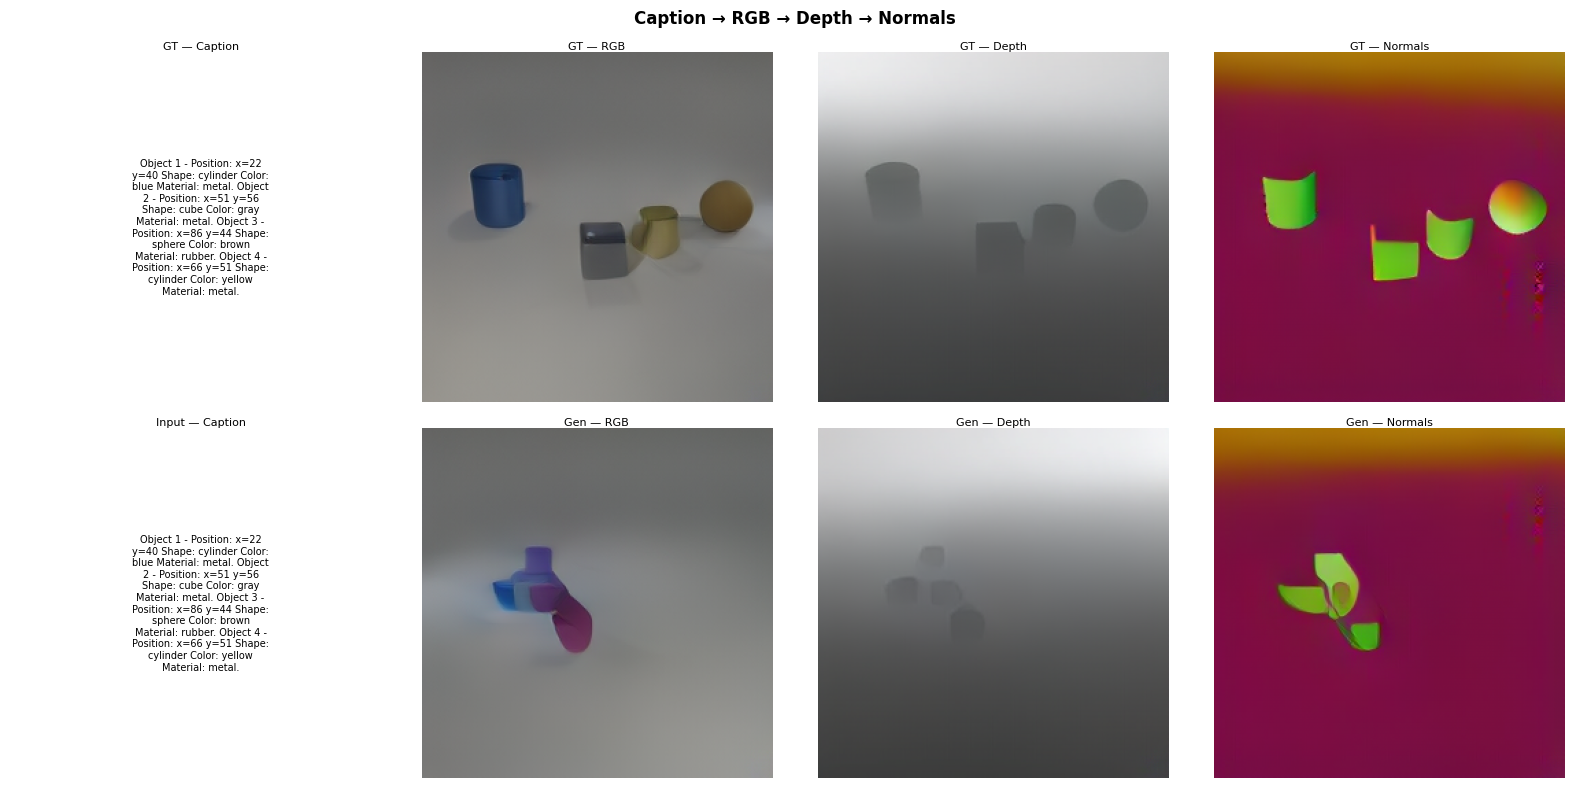

In [7]:
SAMPLE_IDX = 3   # change to explore different samples

chain_targets = [
    ('scene_desc',    'Caption',  None, None, None),
    ('tok_rgb@256',   'RGB',       64,  0.7,  0.9),
    ('tok_depth@256', 'Depth',     64,  0.7,  0.9),
    ('tok_normal@256','Normals',   64,  0.7,  0.9),
]

x_tok, x_pos, x_mod = construct_input(SAMPLE_IDX, 'scene_desc')

fig, axes = plt.subplots(2, len(chain_targets), figsize=(4*len(chain_targets), 8))
fig.suptitle('Caption → RGB → Depth → Normals', fontsize=12, fontweight='bold')

for col, (tmod, label, steps, temp, top_p) in enumerate(chain_targets):
    gt = dataset[SAMPLE_IDX][tmod]
    show_modality(gt.unsqueeze(0), tmod, axes[0, col], f'GT — {label}')
    if steps is None:
        show_modality(x_tok, tmod, axes[1, col], f'Input — {label}')
    else:
        pred, x_tok, x_pos, x_mod = generate(model, x_tok, x_pos, x_mod,
                                              tmod, steps, temp, top_p)
        show_modality(pred, tmod, axes[1, col], f'Gen — {label}')

axes[0, 0].set_ylabel('Ground truth', fontsize=10)
axes[1, 0].set_ylabel('Generated',    fontsize=10)
plt.tight_layout()
plt.show()


### 4.2 RGB → Depth → Normals → Caption

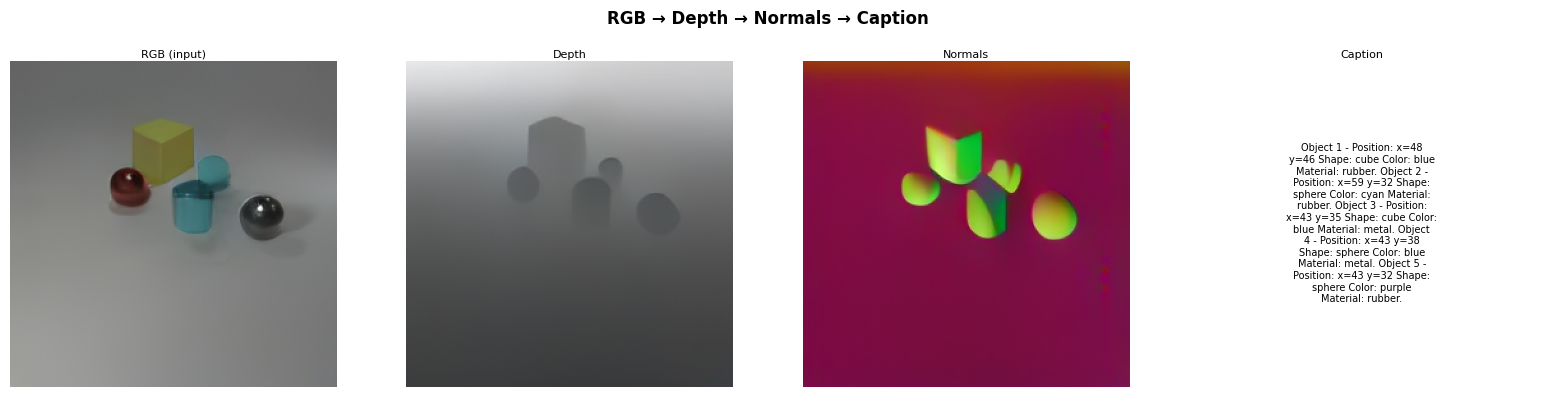

In [8]:
SAMPLE_IDX = 7

x_tok, x_pos, x_mod = construct_input(SAMPLE_IDX, 'tok_rgb@256')

targets = [
    ('tok_rgb@256',   'RGB (input)', None, None, None),
    ('tok_depth@256', 'Depth',        64,  0.7,  0.9),
    ('tok_normal@256','Normals',      64,  0.7,  0.9),
    ('scene_desc',    'Caption',     128,  0.7,  0.9),
]

fig, axes = plt.subplots(1, len(targets), figsize=(4*len(targets), 4))
fig.suptitle('RGB → Depth → Normals → Caption', fontsize=12, fontweight='bold')

for col, (tmod, label, steps, temp, top_p) in enumerate(targets):
    if steps is None:
        show_modality(x_tok, tmod, axes[col], label)
    else:
        pred, x_tok, x_pos, x_mod = generate(model, x_tok, x_pos, x_mod,
                                              tmod, steps, temp, top_p)
        show_modality(pred, tmod, axes[col], label)
plt.tight_layout()
plt.show()


## 5. Baseline vs best variant comparison

Load two models and compare their Caption → RGB generation side by side.

In [9]:
model_baseline = load_model_from_hf('baseline_v1')
model_best     = load_model_from_hf('swiglu_depth16_residual_depth_deepnorm')


Loading baseline_v1 / checkpoint-final.safetensors from HuggingFace …
  ✓ baseline_v1/checkpoint-final.safetensors  (109.9M params)
Loading swiglu_depth16_residual_depth_deepnorm / checkpoint-final.safetensors from HuggingFace …
  ✓ swiglu_depth16_residual_depth_deepnorm/checkpoint-final.safetensors  (216.8M params)


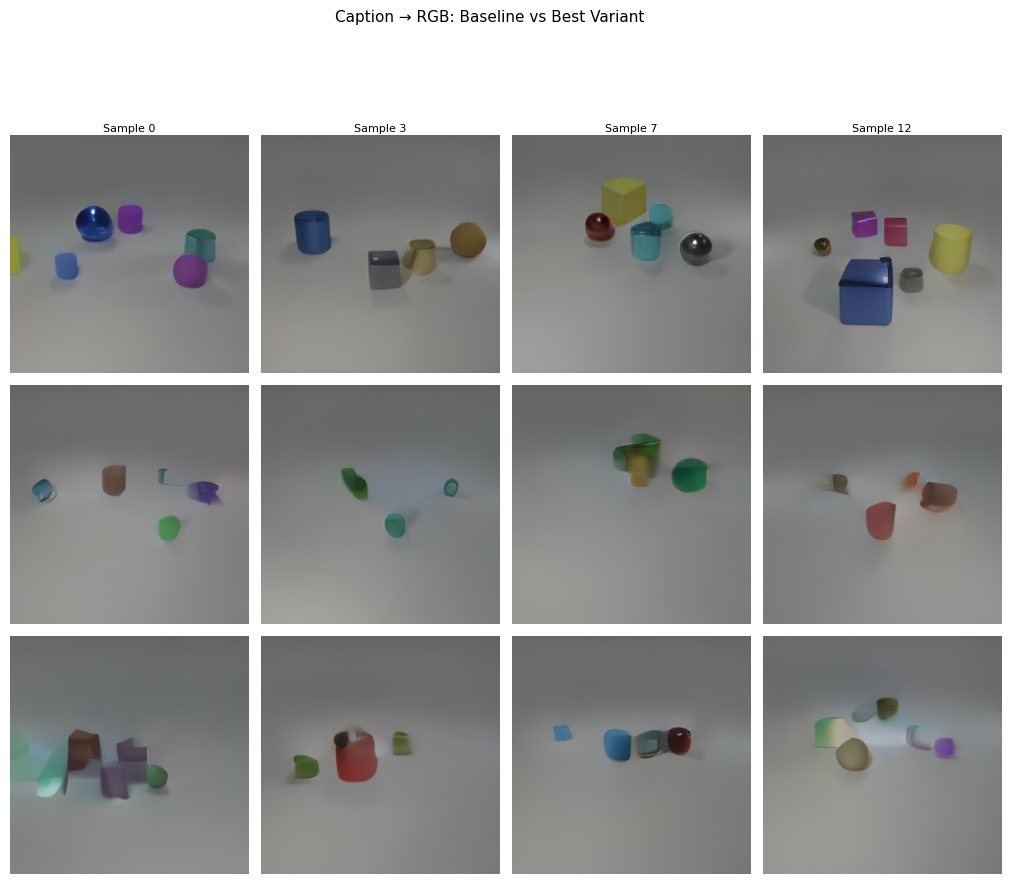

Saved qual_grid.pdf / qual_grid.png


In [10]:
SAMPLE_INDICES = [0, 3, 7, 12]
MODELS_ROW = [
    (None,          'Ground Truth'),
    (model_baseline,'Baseline (D6, GELU, 110M)'),
    (model_best,    'SwD16 + ResScale + DeepNorm (217M)'),
]

N = len(SAMPLE_INDICES)
fig, axes = plt.subplots(len(MODELS_ROW), N,
                         figsize=(3.2*N, 3.2*len(MODELS_ROW)),
                         gridspec_kw={'hspace': 0.05, 'wspace': 0.05})
fig.suptitle('Caption → RGB: Baseline vs Best Variant', fontsize=11, y=1.01)

for col, idx in enumerate(SAMPLE_INDICES):
    gt_tokens = dataset[idx]['tok_rgb@256']
    for row, (mdl, row_label) in enumerate(MODELS_ROW):
        ax = axes[row, col]
        if mdl is None:
            show_modality(gt_tokens.unsqueeze(0), 'tok_rgb@256', ax,
                          title=f'Sample {idx}' if row == 0 else '')
        else:
            x_tok, x_pos, x_mod = construct_input(idx, 'scene_desc')
            pred, *_ = generate(mdl, x_tok, x_pos, x_mod, 'tok_rgb@256')
            show_modality(pred, 'tok_rgb@256', ax, title='')
        if col == 0:
            ax.set_ylabel(row_label, fontsize=8, labelpad=4)

plt.savefig('qual_grid.pdf', bbox_inches='tight', dpi=150)
plt.savefig('qual_grid.png', bbox_inches='tight', dpi=150)
plt.show()


In [ ]:
model_rope_swiglu = load_model_from_hf("rope_swiglu_v1")

SAMPLE_INDICES = [0, 3, 7, 12]
MODELS_ROW = [
    (None,            "Ground Truth"),
    (model_baseline,  "Baseline (D6, GELU, 110M)"),
    (model_rope_swiglu, "RoPE + SwiGLU (122M, best CF)"),
]

N = len(SAMPLE_INDICES)
fig, axes = plt.subplots(len(MODELS_ROW), N,
                         figsize=(3.2*N, 3.2*len(MODELS_ROW)),
                         gridspec_kw={"hspace": 0.05, "wspace": 0.05})
fig.suptitle("Caption → RGB: Baseline vs Best Compute-Fair Model", fontsize=11, y=1.01)

for col, idx in enumerate(SAMPLE_INDICES):
    gt_tokens = dataset[idx]["tok_rgb@256"]
    for row, (mdl, row_label) in enumerate(MODELS_ROW):
        ax = axes[row, col]
        if mdl is None:
            show_modality(gt_tokens.unsqueeze(0), "tok_rgb@256", ax,
                          title=f"Sample {idx}" if row == 0 else "")
        else:
            x_tok, x_pos, x_mod = construct_input(idx, "scene_desc")
            pred, *_ = generate(mdl, x_tok, x_pos, x_mod, "tok_rgb@256")
            show_modality(pred, "tok_rgb@256", ax, title="")
        if col == 0:
            ax.set_ylabel(row_label, fontsize=8, labelpad=4)

plt.savefig("qual_grid_cf.pdf", bbox_inches="tight", dpi=150)
plt.savefig("qual_grid_cf.png", bbox_inches="tight", dpi=150)
plt.show()

## 6. Load a compute-fair intermediate checkpoint

The HuggingFace repo includes the intermediate checkpoints used for compute-fair evaluation.

In [11]:
# depth16: fair ≈ 3050M tokens → step 22889
model_cf = load_model_from_hf('depth16_v1',
                               checkpoint='checkpoint-22889.safetensors')

# swiglu_depth16: fair ≈ 2540M tokens → step 15259
# model_cf = load_model_from_hf('swiglu_depth16',
#                                checkpoint='checkpoint-15259.safetensors')


Loading depth16_v1 / checkpoint-22889.safetensors from HuggingFace …
  ✓ depth16_v1/checkpoint-22889.safetensors  (183.3M params)


## 7. Flexible multi-model comparison

Template to compare any set of models on the same samples.  
Edit `MODELS_TO_COMPARE` and `SAMPLE_INDICES` then run.


Loading baseline_v1 / checkpoint-final.safetensors from HuggingFace …
  ✓ baseline_v1/checkpoint-final.safetensors  (109.9M params)
Loading swiglu_v1 / checkpoint-final.safetensors from HuggingFace …


checkpoint-final.safetensors:   0%|          | 0.00/490M [00:00<?, ?B/s]

swiglu.yaml: 0.00B [00:00, ?B/s]

  ✓ swiglu_v1/checkpoint-final.safetensors  (122.4M params)
Loading swiglu_depth16_residual_depth_deepnorm / checkpoint-final.safetensors from HuggingFace …
  ✓ swiglu_depth16_residual_depth_deepnorm/checkpoint-final.safetensors  (216.8M params)


/tmp/3436402/ipykernel_3719078/1281100273.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


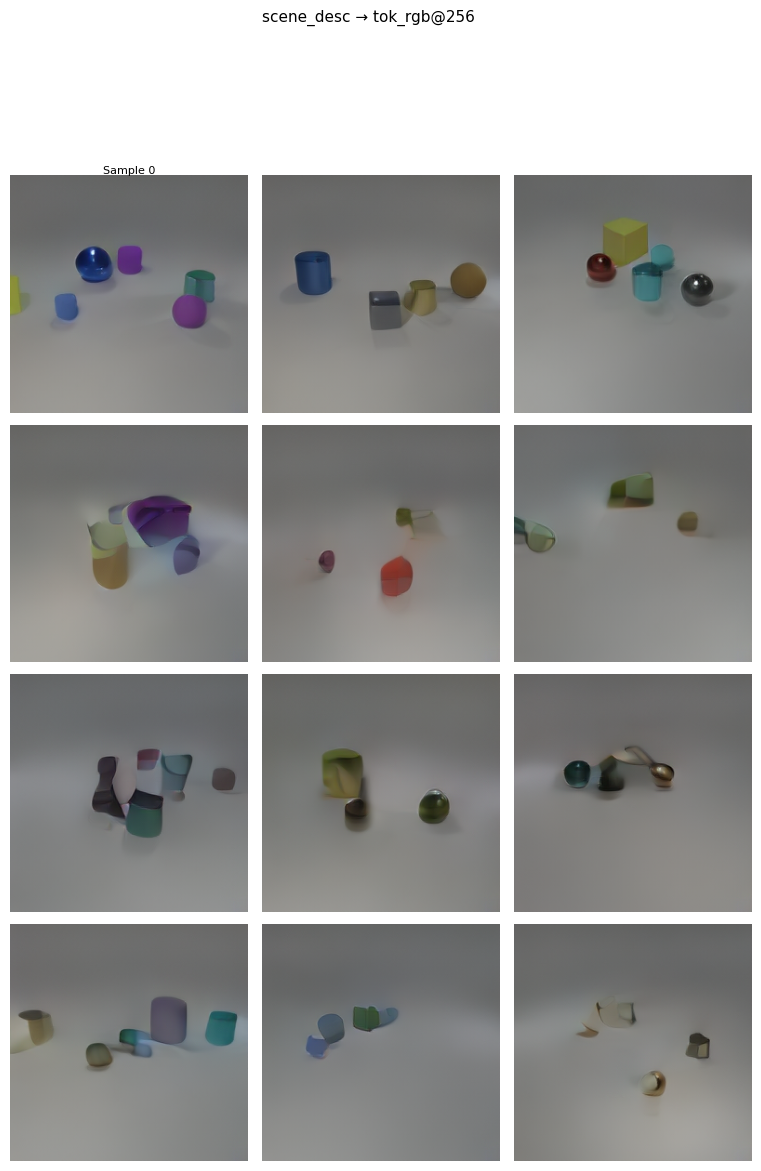

In [12]:
# ── Configure here ───────────────────────────────────────────────────────
SAMPLE_INDICES = [0, 3, 7]          # val-set sample indices
TARGET_MOD     = 'tok_rgb@256'      # modality to generate
INPUT_MOD      = 'scene_desc'       # conditioning modality
GEN_STEPS      = 64

MODELS_TO_COMPARE = [
    ('baseline_v1',                            'checkpoint-final.safetensors', 'Baseline'),
    ('swiglu_v1',                              'checkpoint-final.safetensors', 'SwiGLU'),
    ('swiglu_depth16_residual_depth_deepnorm', 'checkpoint-final.safetensors', 'Best'),
    # Add or remove rows freely — format: (exp_name, checkpoint, display_label)
    # To load a local model, pass a loaded model object directly (see load_model_local)
]
# ─────────────────────────────────────────────────────────────────────────

# Load models (skips if already loaded with same key)
_model_cache = {}
def get_model(exp_name, checkpoint):
    key = (exp_name, checkpoint)
    if key not in _model_cache:
        _model_cache[key] = load_model_from_hf(exp_name, checkpoint)
    return _model_cache[key]

n_rows = 1 + len(MODELS_TO_COMPARE)  # GT + one row per model
n_cols = len(SAMPLE_INDICES)
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(3.2*n_cols, 3.2*n_rows),
                         gridspec_kw={'hspace': 0.05, 'wspace': 0.05})
if n_cols == 1: axes = axes[:, None]  # ensure 2D

for col, idx in enumerate(SAMPLE_INDICES):
    gt = dataset[idx][TARGET_MOD]
    show_modality(gt.unsqueeze(0), TARGET_MOD, axes[0, col],
                  title=f'Sample {idx}' if col == 0 else '')
    if col == 0: axes[0, col].set_ylabel('Ground Truth', fontsize=8)

    for row, (exp_name, ckpt, label) in enumerate(MODELS_TO_COMPARE, start=1):
        mdl = get_model(exp_name, ckpt)
        x_tok, x_pos, x_mod = construct_input(idx, INPUT_MOD)
        pred, *_ = generate(mdl, x_tok, x_pos, x_mod, TARGET_MOD,
                            num_steps=GEN_STEPS)
        show_modality(pred, TARGET_MOD, axes[row, col], title='')
        if col == 0: axes[row, col].set_ylabel(label, fontsize=8)

fig.suptitle(f'{INPUT_MOD} → {TARGET_MOD}', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


---
*Generated with the nano4M Architecture Improvements project — COM-304, EPFL Spring 2026.*